# Exercise 4.9 - part 2

## Table of content
1.1 Importing Libraries

1.2 Importing Data Sets

2. Creating Charts
3. Histogram on 'order_hour_of_day'
4. Bar Chart on 'loyalty_flag'
5. Line chart on expenditure
6. Line chart on 'age' and 'number_of_dependants'
7. Scatterplot on 'age' and 'income'

# 1.1. Importing Libraries

In [3]:
# Importing the analysis and visualization libraries

In [4]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

# 1.2 Importing Data Sets

In [6]:
# Creating a path

In [7]:
path=r'/Users/konstant/Documents/Achievement 4. Instacart Basket Analysis'

In [8]:
# Importing most up-to-date project data

In [9]:
df_final_merge= pd.read_pickle(os.path.join(path, '02 Data','Prepared Data','df_final_merge.pkl'))

In [10]:
# checking results of the imported data set. 

In [11]:
df_final_merge.head(2)

,product_id,product_name,aisle_id,department_id,prices,order_id,user_id,order_number,orders_day_of_week,hour_of_purchase,...,first_name,last_name,gender,state,age,date_joined,num_of_dependants,fam_status,income,_merge
0,1,Chocolate Sandwich Cookies,61,19,5.8,3139998,138,28,6,11,...,Charles,Cox,Male,Minnesota,81,8/1/2019,1,married,49620,both
1,1,Chocolate Sandwich Cookies,61,19,5.8,1977647,138,30,6,17,...,Charles,Cox,Male,Minnesota,81,8/1/2019,1,married,49620,both


In [12]:
df_final_merge.shape

(32404859, 32)

# 2. Creating Charts

## Creating a bar chart

In [15]:
# Creating a bar chart with the variable 'orders_day_of_week'

<Axes: xlabel='orders_day_of_week'>

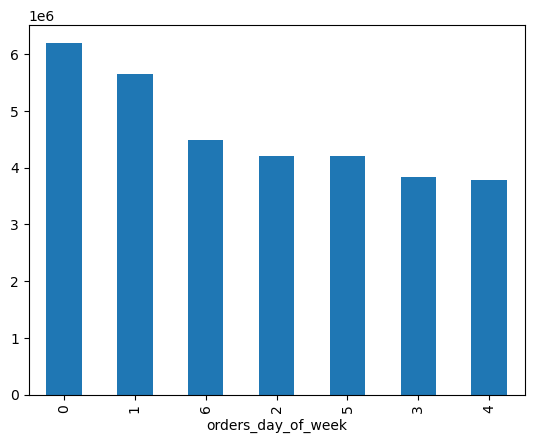

In [16]:
df_final_merge['orders_day_of_week'].value_counts().plot.bar()

In [17]:
# rearranging the x-axis

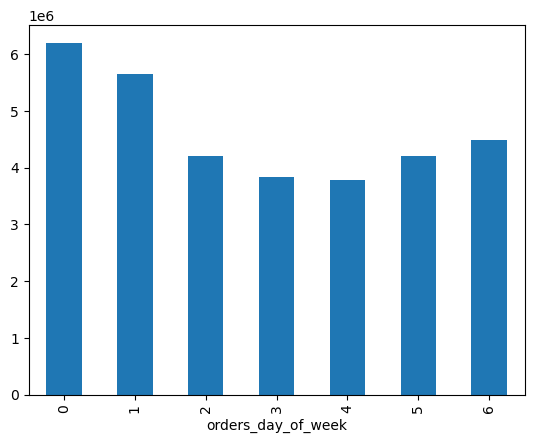

In [18]:
bar=df_final_merge['orders_day_of_week'].value_counts().sort_index().plot.bar()

In [19]:
# Adding colour to the bar-chart

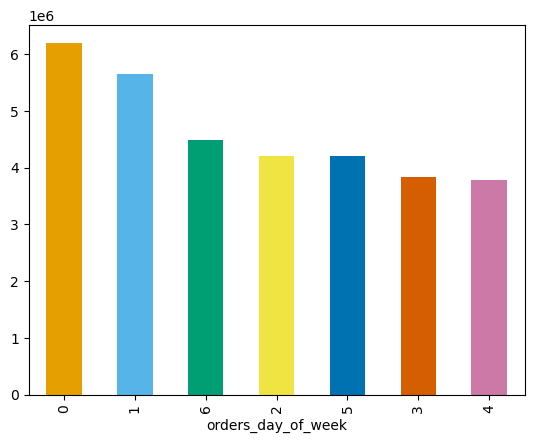

In [20]:
bar=df_final_merge['orders_day_of_week'].value_counts().plot.bar(color=['#E69F00','#56B4E9','#009E73','#F0E442','#0072B2','#D55E00','#CC79A7'])

In [21]:
# Exporting the bar chart as a png file

In [22]:
bar.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'bar_orders_dow.png'))

## Creating a histogram - part 1

In [24]:
# Creating a histogram of the variable 'price'

<Axes: ylabel='Frequency'>

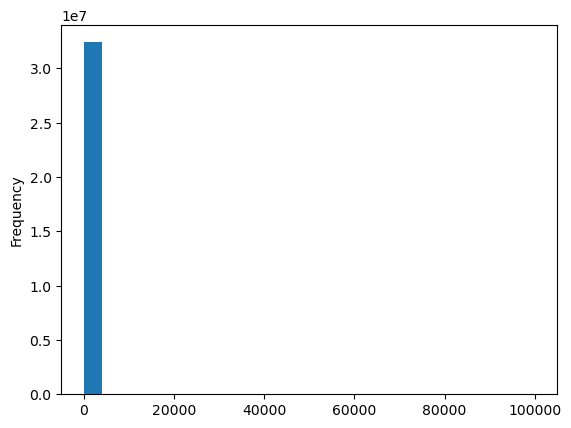

In [25]:
df_final_merge['prices'].plot.hist(bins = 25)

In [26]:
# The chart does not look correct. Further investigating the descriptive statistics

In [27]:
df_final_merge['prices'].describe()

count    3.240486e+07
mean     1.198023e+01
std      4.956554e+02
min      1.000000e+00
25%      4.200000e+00
50%      7.400000e+00
75%      1.130000e+01
max      9.999900e+04
Name: prices, dtype: float64

In [28]:
# The max value looks odd. Further investigating by conducting a few checks for each specific statistic.

In [29]:
df_final_merge['prices'].mean()

11.980225638383468

In [30]:
df_final_merge['prices'].median()

7.4

In [31]:
df_final_merge['prices'].max()

99999.0

In [32]:
# The mean and median looks ok, but the max is off and is the reason for breaking the histogram. 

In [33]:
# Now further exploring the data by means of a scatterplot. 

## Creating a scatterplot

<Axes: xlabel='prices', ylabel='prices'>

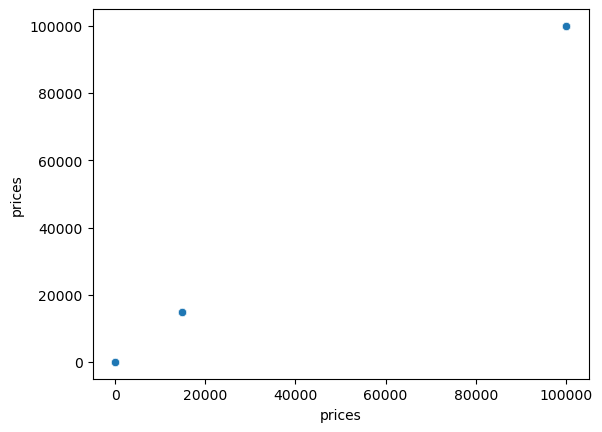

In [35]:
sns.scatterplot(x = 'prices', y = 'prices',data = df_final_merge)

In [36]:
# The mean of the column is around 12, so the first point makes sense. The max is also close to 100,000, and the furthest point makes sense. 

In [37]:
# There is another value close to 20,000 which is needs further investigation. 

In [38]:
# checking if there are any values above a certain threshold (100). 

In [39]:
df_final_merge.loc[df_final_merge['prices'] > 100]

,product_id,product_name,aisle_id,department_id,prices,order_id,user_id,order_number,orders_day_of_week,hour_of_purchase,...,first_name,last_name,gender,state,age,date_joined,num_of_dependants,fam_status,income,_merge
13100147,21553,Lowfat 2% Milkfat Cottage Cheese,108,16,14900.0,912404,17,12,2,14,...,Barbara,Chang,Female,Kansas,39,9/16/2018,3,married,150659,both
13100148,21553,Lowfat 2% Milkfat Cottage Cheese,108,16,14900.0,603376,17,22,6,16,...,Barbara,Chang,Female,Kansas,39,9/16/2018,3,married,150659,both
13100149,21553,Lowfat 2% Milkfat Cottage Cheese,108,16,14900.0,3264360,135,2,2,21,...,nan,Chen,Female,Maryland,30,3/19/2017,3,married,120635,both
13100150,21553,Lowfat 2% Milkfat Cottage Cheese,108,16,14900.0,892534,135,3,0,8,...,nan,Chen,Female,Maryland,30,3/19/2017,3,married,120635,both
13100151,21553,Lowfat 2% Milkfat Cottage Cheese,108,16,14900.0,229704,342,8,1,19,...,Ruby,Bates,Female,Minnesota,56,8/23/2018,2,married,187328,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21786876,33664,2 % Reduced Fat Milk,84,16,99999.0,2249946,204099,29,0,8,...,Gary,Wilson,Male,Washington,48,9/8/2019,3,married,536156,both
21786877,33664,2 % Reduced Fat Milk,84,16,99999.0,2363282,204099,31,0,9,...,Gary,Wilson,Male,Washington,48,9/8/2019,3,married,536156,both
21786878,33664,2 % Reduced Fat Milk,84,16,99999.0,3181945,204395,13,3,15,...,Shirley,Ellis,Female,Missouri,78,11/9/2019,3,married,137004,both
21786879,33664,2 % Reduced Fat Milk,84,16,99999.0,2486215,205227,7,3,20,...,Victor,Rivers,Male,Arizona,78,8/9/2018,3,married,294898,both


In [40]:
# 5,127 rows that has a vlaue higher than 100. In addition, at the top of the “prices” column, you can see that there’s another odd value, €14,900.00, which corresponds to the second unexplainable point in the scatterplot


In [41]:
# As such, we can assume that it’s the €14,900.00 and €99,999.00 values that are skewing the chart and they should be marked as missing since they dont make any sense. 


In [42]:
# Deploying function to assign missing values to 'np.nan'

In [43]:
df_final_merge.loc[df_final_merge['prices'] >100, 'prices'] = np.nan

In [44]:
# Checking wether the replacement was successful with the max_value check.

In [45]:
df_final_merge['prices'].max()

25.0

In [46]:
# from the result above, we can see that the max value is 25, which is correct.

## Creating a histogram - part 2

In [48]:
# after the ad-hoc data cleaning, produce the histogram again.

<Axes: ylabel='Frequency'>

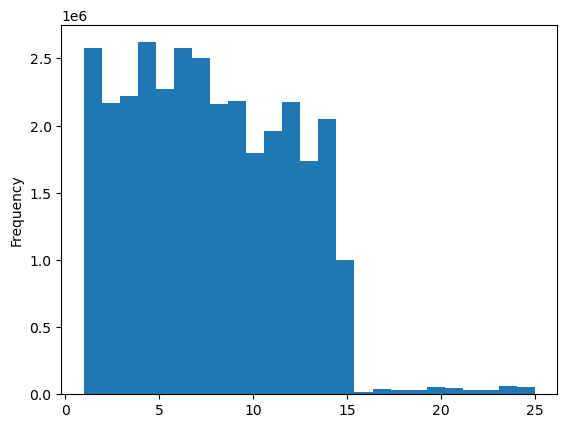

In [49]:
df_final_merge['prices'].plot.hist(bins = 25)

In [50]:
# increasing the level of granularity, by increasing the number of bins

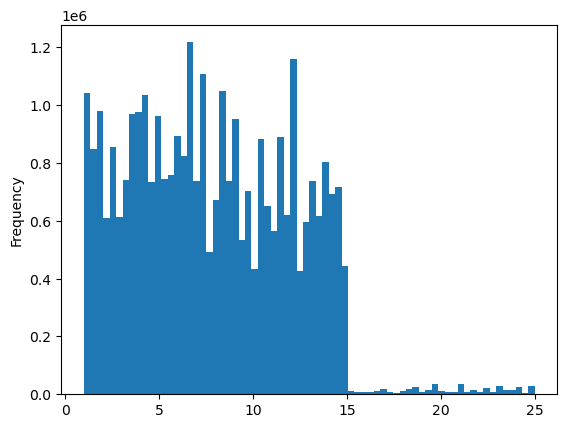

In [51]:
hist=df_final_merge['prices'].plot.hist(bins = 70)

In [52]:
# Exporting the histogram as a png file

In [53]:
hist.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'histogram_prods_price.png'))

## Creating a line chart

In [55]:
# Creating a list holding True/False values to the test np.random.rant() <= 0.70

In [56]:
np.random.seed(4)
dev = np.random.rand(len(df_final_merge)) <= 0.7

In [57]:
# Store 70% of the sample in the dataframe 'big'

In [58]:
big = df_final_merge[dev]

In [59]:
# Store 30% of the sample in the dataframe 'small'

In [60]:
small=df_final_merge[~dev]

In [61]:
# Checking the lenght of the complete data frame

In [62]:
len(df_final_merge)

32404859

In [63]:
# Now cross checking the 70/30 split, by adding the lenght up. 

In [64]:
len(big) + len(small)

32404859

In [65]:
# The result above matches the number of rows for the total data set, which means the split is successful. 

In [66]:
# Now filtering out only the columns that we need for the chart from the small sample size. 

In [67]:
df_2 = small[['orders_day_of_week','prices']]

In [68]:
# Now ready to create the line chart for 'price' and 'orders_day_of_week'

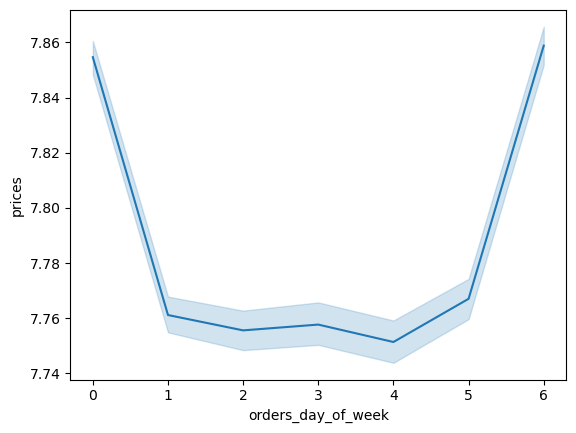

In [69]:
line = sns.lineplot(data = df_2, x = 'orders_day_of_week',y = 'prices')

In [70]:
# # Exporting the line chart as a png file

In [71]:
line.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'line_price_orders_dow.png'))

In [72]:
# Getting a list of the column names

In [73]:
df_final_merge.columns.tolist()

['product_id',
 'product_name',
 'aisle_id',
 'department_id',
 'prices',
 'order_id',
 'user_id',
 'order_number',
 'orders_day_of_week',
 'hour_of_purchase',
 'days_since_prior_order',
 'add_to_cart_order',
 'reordered',
 'price_range_loc',
 'busiest_days',
 'busiest_period_of_day',
 'max_order',
 'loyalty_flag',
 'max_spend',
 'spending_flag',
 'days_since_last_order_median',
 'order_frequency_flag',
 'first_name',
 'last_name',
 'gender',
 'state',
 'age',
 'date_joined',
 'num_of_dependants',
 'fam_status',
 'income',
 '_merge']

## 3. Histogram on 'order_hour_of_day'

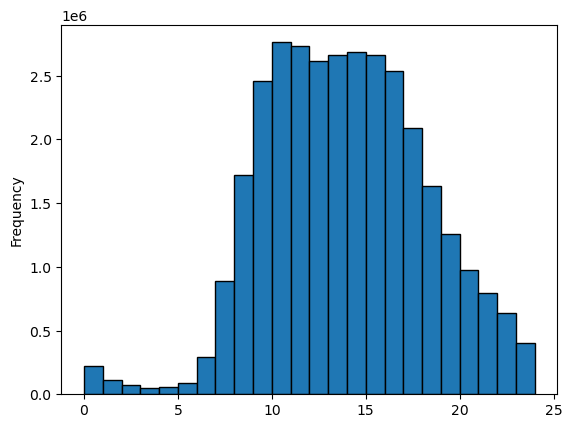

In [75]:
hist_hour_of_purchase=df_final_merge['hour_of_purchase'].plot.hist(bins=range(0,25),edgecolor='black')

### From the histogram, we can gather that sales are the lowest between hours 0-5. From hour 6 sales start to increase and peaks between hours 10 to 15. From hour 16 the sales decrease gradually until hour 23. This is a typical bell shaped histogram, where the majority of the orders are concentrated in the middle of the histogram. 

In [77]:
# Exporting chart as png file

In [78]:
hist_hour_of_purchase.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'hist_hour_of_purchase.png'))


# 4. Bar Chart on 'loyalty_flag'

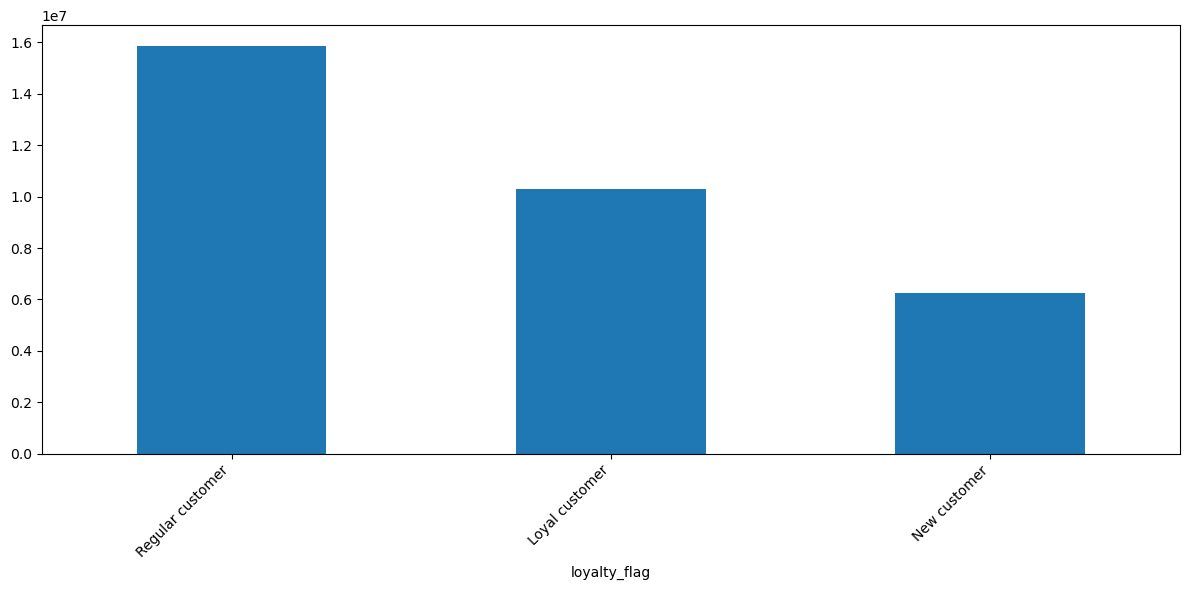

In [80]:
plt.figure(figsize=(12, 6))
bar_loyalty_flag=df_final_merge['loyalty_flag'].value_counts().plot.bar()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [81]:
# Exporting chart as png file

In [82]:
bar_loyalty_flag.figure.savefig(os.path.join(path,'04 Analysis','Visualizations', 'bar_loyalty_flag.png'))

# 5. Line chart on expenditure

In [84]:
# 70/30 sample split was already created. Using the 30% sample to create the line chart. 

In [85]:
# Creating a new data frame df_3 from the small sample size.

In [86]:
df_3 = small[['hour_of_purchase','prices']]

In [87]:
# Now ready to create the line chart for 'price' and 'hour_of_purchase'

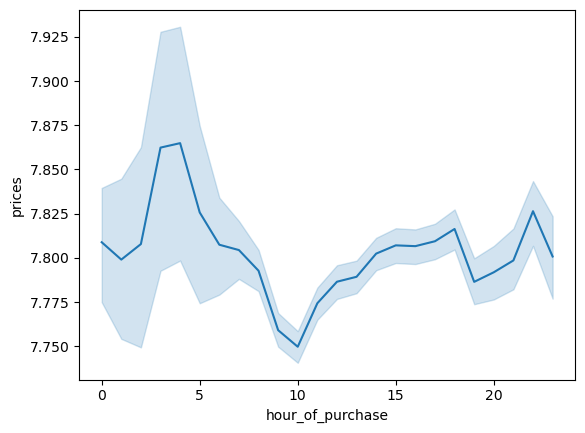

In [88]:
line_expenditure=sns.lineplot(data = df_3, x = 'hour_of_purchase',y = 'prices')

In [89]:
# Exporting chart as png file.

In [90]:
line_expenditure.figure.savefig(os.path.join(path,'04 Analysis','Visualizations', 'line_expenditure.png'))

# 6. Line chart on 'age' and 'number_of_dependants'

In [92]:
# Creating a new data frame df_4 from the small sample size.

In [93]:
df_4 = small[['age','num_of_dependants']]

In [94]:
# Now ready to create the line chart to check if there is a connection between 'age' and 'num_of_dependants'

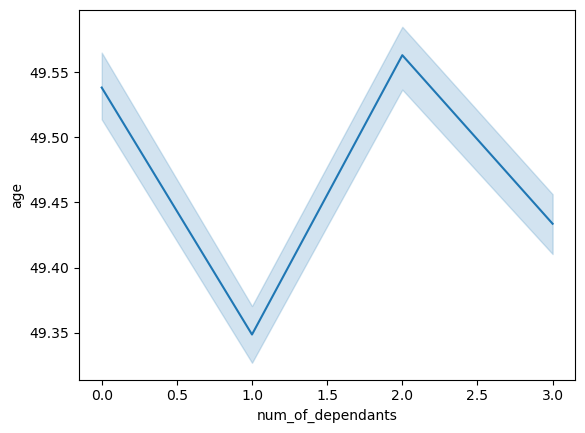

In [95]:
line_age_dependants=sns.lineplot(data = df_4, x = 'num_of_dependants',y = 'age')

### -In this line chart, the age on the y-axes is aggregated to the mean age (in this chart 49 years). On the x-axes, we can see that the highest density of dependants is 2, sitting with the age group 49 years.

In [97]:
# Exporting the chart as a png file.

In [98]:
line_age_dependants.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'line_age_dependants.png'))

# 7. Scatterplot on 'age' and 'income'

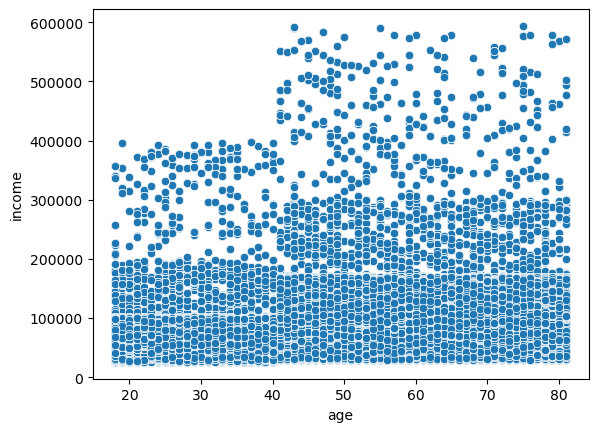

In [100]:
scat_age_income=sns.scatterplot(x = 'age', y = 'income',data = df_final_merge)

### The scatterplot shows that all age groups earn at least +- 20,000 of income. From age 18 - 40 the income is a bit scattered between 20k and 40k, while no one in this age group earns above 40k. People aged between 40 and 80 also have a concentrated earning bracket between 20K to 30K (although less than the 0 - 20K bracket). The same age group has scattered earnings between 30k and 60k, where the portion of people earning higher salaries becomes thinner towards the ceiling. 

In [102]:
# exporting chart as png

In [103]:
scat_age_income.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'scat_age_income.png'))